## 1.1 Import Required Libraries

In [41]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Data profiling
from ydata_profiling import ProfileReport

# Statistical tests
from scipy import stats
from scipy.stats import chi2_contingency, normaltest

# Utilities
import warnings
import os
from datetime import datetime

warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1.2 Data Acquisition

Load data set from ucimlrepo

In [42]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
heart_disease = fetch_ucirepo(id=45) 
  
# data (as pandas dataframes) 
X = heart_disease.data.features 
y = heart_disease.data.targets 

# Combine features and target into a single dataframe
df = pd.concat([X, y], axis=1)

# Rename target column for consistency
df = df.rename(columns={df.columns[-1]: 'target'})

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")

# Display metadata 
print("\n" + "="*50)
print("DATASET METADATA:")
print("="*50)
print(heart_disease.metadata)

print("\n" + "="*50)
print("VARIABLE INFORMATION:")
print("="*50)
print(heart_disease.variables)

Dataset loaded successfully!
Shape: (303, 14)

DATASET METADATA:
{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary arte

## 1.3 Initial Data Inspection

In [43]:
# Display first few rows
print("First 5 rows:")
display(df.head())

print("\nRandom sample:")
display(df.sample(5))

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0



Random sample:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
136,70,1,4,145,174,0,0,125,1,2.6,3,0.0,7.0,4
186,42,1,3,120,240,1,0,194,0,0.8,3,0.0,7.0,0
156,51,1,4,140,299,0,0,173,1,1.6,1,0.0,7.0,1
203,64,0,3,140,313,0,0,133,0,0.2,1,0.0,7.0,0
244,60,0,3,120,178,1,0,96,0,0.0,1,0.0,3.0,0


In [44]:
# Dataset information
print("Dataset Info:")
print("="*50)
df.info()

print("\nData Types:")
print(df.dtypes.value_counts())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB

Data Types:
int64      11
float64     3
Name: count, dtype: int64


## 1.4 Data Quality Assessment

In [45]:
# Quick data quality check
missing_count = df.isnull().sum().sum()
duplicates = df.duplicated().sum()

print("Data Quality Check:")
print("="*50)
print(f"Missing values: {missing_count}")
print(f"Duplicate rows: {duplicates}")
print(f"Shape: {df.shape}")

if missing_count == 0 and duplicates == 0:
    print("\nData is clean and ready for analysis!")
else:
    print("\nData cleaning required")

Data Quality Check:
Missing values: 6
Duplicate rows: 0
Shape: (303, 14)

Data cleaning required


## 1.5 Data Cleaning & Preprocessing

In [46]:
# Handle missing values if any
df_cleaned = df.copy()

missing_summary = df_cleaned.isnull().sum()
missing_summary = missing_summary[missing_summary > 0]

# Numerical columns (float64, int64): Fills missing values with the median (middle value, robust to outliers)
# Categorical columns: Fills missing values with the mode (most frequent value)
if len(missing_summary) > 0:
    print("Handling missing values...")
    for col in missing_summary.index:
        if df_cleaned[col].dtype in ['float64', 'int64']:
            df_cleaned[col].fillna(df_cleaned[col].median(), inplace=True)
        else:
            df_cleaned[col].fillna(df_cleaned[col].mode()[0], inplace=True)
    print("Missing values handled")
else:
    print("No missing values found")

# Remove duplicates
duplicates_before = df_cleaned.duplicated().sum()
if duplicates_before > 0:
    df_cleaned = df_cleaned.drop_duplicates()
    print(f"Removed {duplicates_before} duplicate rows")
    
# Update df
df = df_cleaned.copy()
print(f"\nCleaned dataset shape: {df.shape}")

Handling missing values...
Missing values handled

Cleaned dataset shape: (303, 14)


## 1.6 Professional Visualizations

### 1.6.1 Feature Distributions (Histograms)

Creating distribution plots for 13 numerical features...


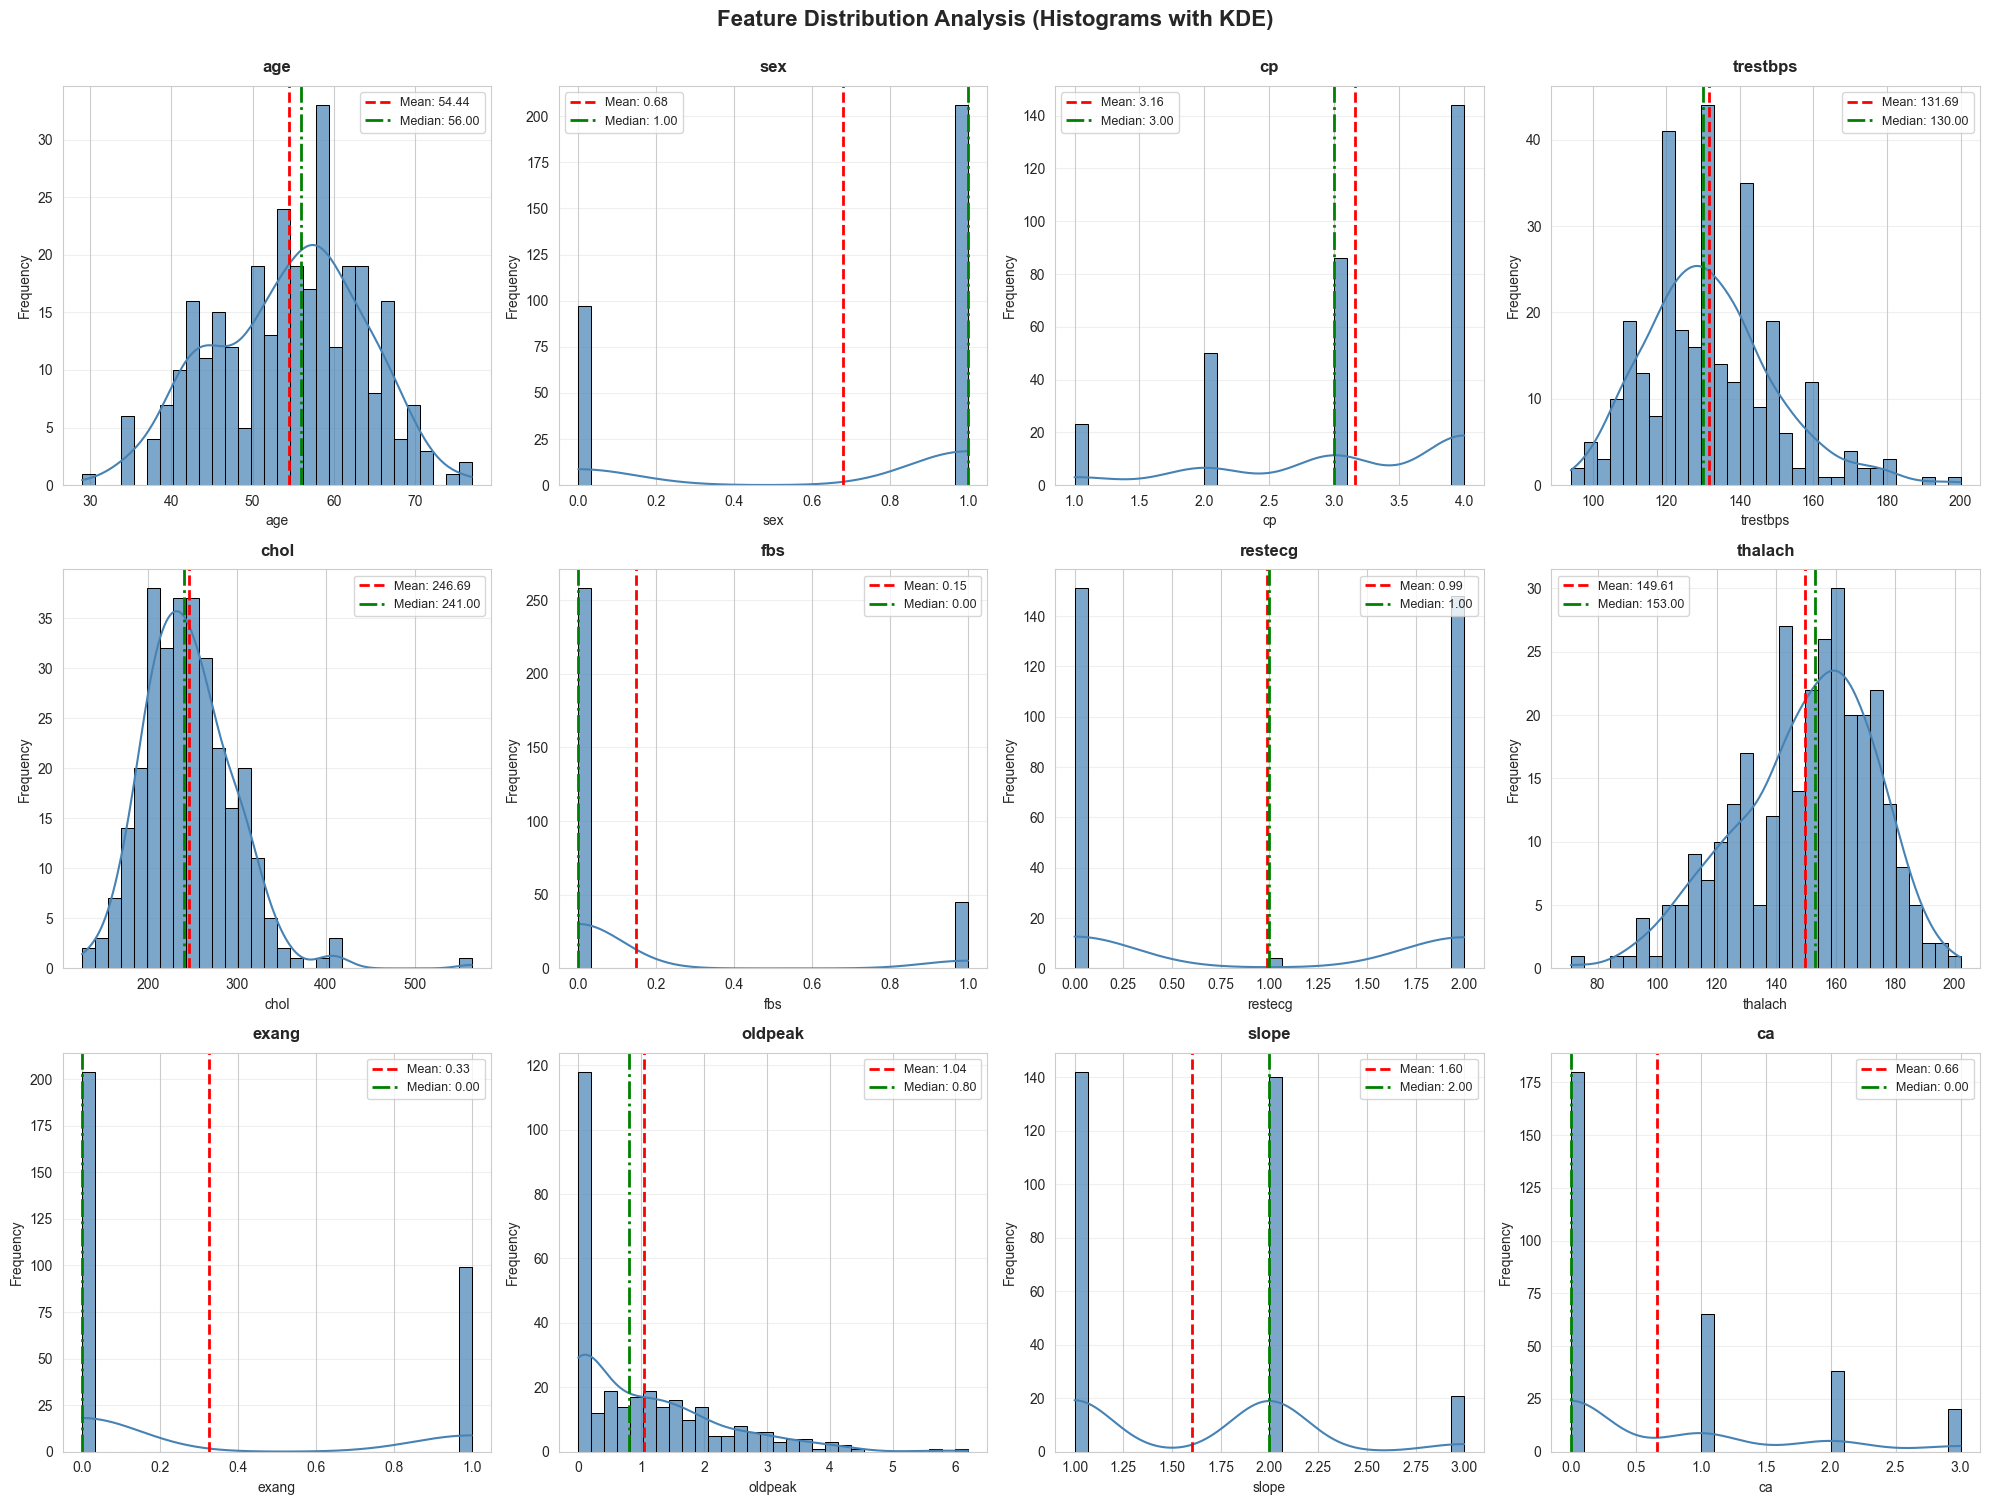

In [47]:
# Professional Histograms for Feature Distributions
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'target' in numeric_cols:
    numeric_cols.remove('target')

print(f"Creating distribution plots for {len(numeric_cols)} numerical features...")

# Select up to 12 features for visualization
n_features = min(len(numeric_cols), 12)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.flatten() if n_features > 1 else [axes]

for idx, col in enumerate(numeric_cols[:n_features]):
    ax = axes[idx]
    
    # Histogram with KDE
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue', 
                edgecolor='black', alpha=0.7, bins=30)
    
    # Add mean and median lines
    mean_val = df[col].mean()
    median_val = df[col].median()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, 
               label=f'Mean: {mean_val:.2f}')
    ax.axvline(median_val, color='green', linestyle='-.', linewidth=2, 
               label=f'Median: {median_val:.2f}')
    
    # Styling
    ax.set_title(f'{col}', fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

# Hide empty subplots
for idx in range(n_features, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Feature Distribution Analysis (Histograms with KDE)', 
            fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

In [48]:
### 1.6.2 Correlation Heatmap

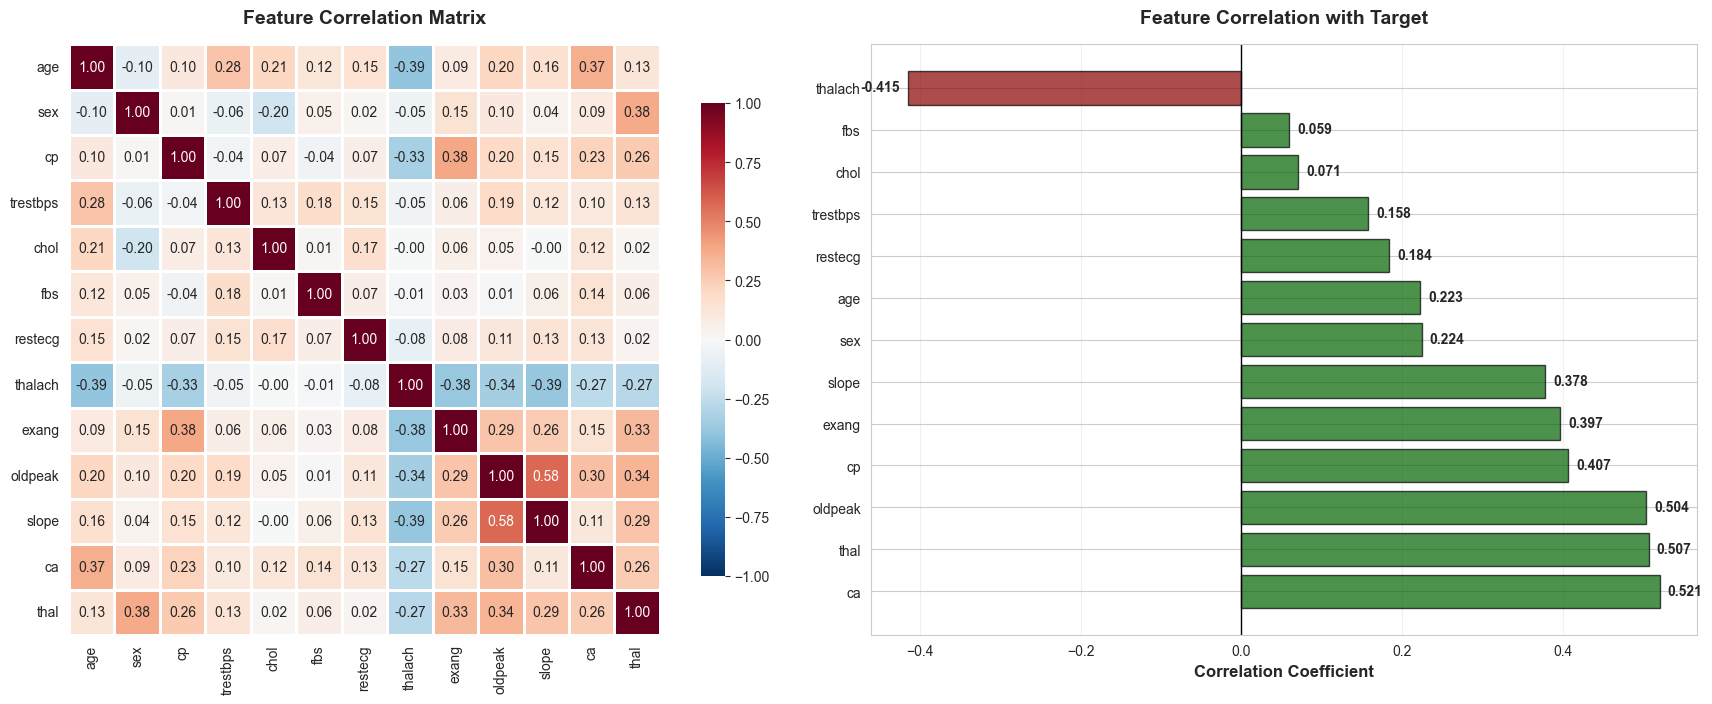

In [49]:
# Professional Correlation Heatmap

correlation_matrix = df[numeric_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Main correlation heatmap
sns.heatmap(correlation_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='RdBu_r',
            center=0, 
            square=True, 
            linewidths=1,
            cbar_kws={"shrink": 0.8},
            vmin=-1, 
            vmax=1,
            ax=axes[0])
axes[0].set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)

# Correlation with target
if 'target' in df.columns:
    target_corr = df[numeric_cols + ['target']].corr()['target'].drop('target').sort_values(ascending=False)
    
    colors = ['darkgreen' if x > 0 else 'darkred' for x in target_corr]
    axes[1].barh(range(len(target_corr)), target_corr, color=colors, alpha=0.7, edgecolor='black')
    axes[1].axvline(x=0, color='black', linestyle='-', linewidth=1)
    axes[1].set_yticks(range(len(target_corr)))
    axes[1].set_yticklabels(target_corr.index)
    axes[1].set_xlabel('Correlation Coefficient', fontsize=12, fontweight='bold')
    axes[1].set_title('Feature Correlation with Target', fontsize=14, fontweight='bold', pad=15)
    axes[1].grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, v in enumerate(target_corr):
        axes[1].text(v + 0.01 if v > 0 else v - 0.01, i, f'{v:.3f}', 
                    va='center', ha='left' if v > 0 else 'right', fontweight='bold')

plt.tight_layout()
plt.show()

### 1.6.3 Class Balance Analysis

Analyzing class balance...


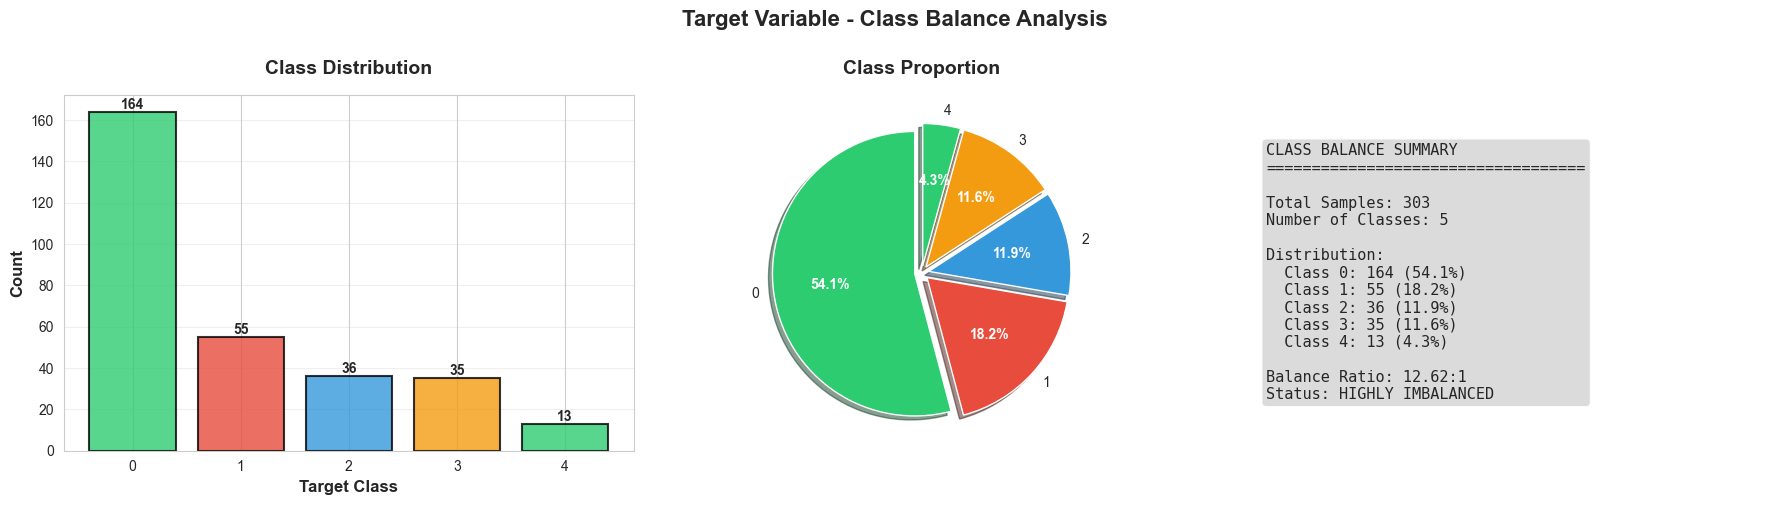

In [50]:
# Professional Class Balance Visualization
print("Analyzing class balance...")

if 'target' in df.columns:
    target_counts = df['target'].value_counts().sort_index()
    target_pct = (target_counts / len(df)) * 100
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Bar plot
    bars = axes[0].bar(target_counts.index, target_counts.values, 
                       color=['#2ecc71', '#e74c3c', '#3498db', '#f39c12'][:len(target_counts)],
                       edgecolor='black', linewidth=1.5, alpha=0.8)
    axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold', pad=15)
    axes[0].set_xlabel('Target Class', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Count', fontsize=12, fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3)
    
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}',
                    ha='center', va='bottom', fontweight='bold')
    
    # Pie chart
    colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12'][:len(target_counts)]
    wedges, texts, autotexts = axes[1].pie(target_counts, 
                                            labels=target_counts.index, 
                                            autopct='%1.1f%%',
                                            startangle=90, 
                                            colors=colors,
                                            explode=[0.05]*len(target_counts),
                                            shadow=True)
    axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold', pad=15)
    
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
    
    # Summary statistics
    axes[2].axis('off')
    balance_ratio = target_counts.max() / target_counts.min()
    
    if balance_ratio <= 1.5:
        status = "BALANCED"
    elif balance_ratio <= 3:
        status = "MODERATELY IMBALANCED"
    else:
        status = "HIGHLY IMBALANCED"
    
    summary = f"CLASS BALANCE SUMMARY\n{'='*35}\n\n"
    summary += f"Total Samples: {len(df):,}\n"
    summary += f"Number of Classes: {len(target_counts)}\n\n"
    summary += "Distribution:\n"
    for cls, count in target_counts.items():
        pct = target_pct[cls]
        summary += f"  Class {cls}: {count:,} ({pct:.1f}%)\n"
    summary += f"\nBalance Ratio: {balance_ratio:.2f}:1\n"
    summary += f"Status: {status}"
    
    axes[2].text(0.1, 0.5, summary, transform=axes[2].transAxes,
                fontsize=11, verticalalignment='center', family='monospace',
                bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    
    plt.suptitle('Target Variable - Class Balance Analysis', 
                fontsize=16, fontweight='bold', y=1.00)
    plt.tight_layout()
    plt.show()
else:
    print("No target column found")

## 1.7 Save Processed Data

In [ ]:
# Save cleaned data and documentation
os.makedirs('data', exist_ok=True)

# Save cleaned data
df.to_csv('data/cleaned_data.csv', index=False)
print("Cleaned data saved to: data/cleaned_data.csv")

# Save features and target separately
if 'target' in df.columns:
    X_df = df.drop('target', axis=1)
    y_df = df[['target']]
    X_df.to_csv('data/X_features.csv', index=False)
    y_df.to_csv('data/y_target.csv', index=False)
    print("Features saved to: data/X_features.csv")
    print("Target saved to: data/y_target.csv")

Cleaned data saved to: data/cleaned_data.csv
Features saved to: data/X_features.csv
Target saved to: data/y_target.csv
